In [ ]:
import numpy as np
import netCDF4
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import LESProcessing as lesP

# Set image parameters for the notebook
plt.rcParams['figure.figsize'] = [10.0, 6.0]
plt.rcParams['figure.dpi'] = 80
plt.rcParams['savefig.dpi'] = 400

plt.rcParams['font.size'] = 18
plt.rcParams['legend.fontsize'] = 'large'
plt.rcParams['figure.titlesize'] = 'large'

file_num = 24
file_num_str = str(file_num).zfill(2)

filename1 = ('LES/4/PrecipEMUSCU_snd_0' +
                 file_num_str + '/OUT_2D/EMULATOR_SCU_240x240x250_dx200_dz10_dt1s_12h_240_mod.2Dbin_1.nc')

nc_H = Dataset(filename1)
ZCT = nc_H.variables['ZCT'][:]
ZCB = nc_H.variables['ZCB'][:]
PREC = nc_H.variables['PREC'][:]
QCLOPD = nc_H.variables['QCLOPD'][:]
CWP = nc_H.variables['CWP'][:]

# Define cloud height
H = ZCT - ZCB # meters

print(file_num_str)


24


In [6]:
#This takes about 10-15minutes to run 
TW = 8
PREC8 = lesP.get_X_ave(PREC,TW,CWP,0)
H8 = lesP.get_X_ave(H,TW,CWP,0)

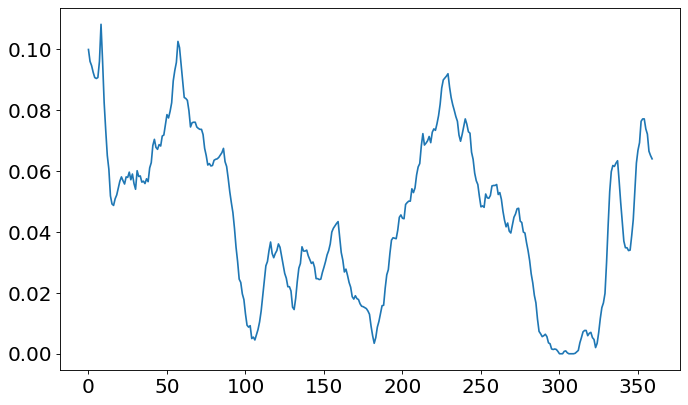

(360, 30, 30)


In [7]:
plt.plot(H8[:,2,12])
plt.show()
print(H8.shape)

# Generate NC file for tiling field

In [ ]:
lesP.save_tile_width_nc_file(X         = H,
                        file_name = ('LES/4/Precip/EMUSCU_snd_0' +
                                         file_num_str + '/EMUSCU_snd_0' + file_num_str + '_tw8.nc'),
                        LES_nc    =nc_H,
                        threshold_parameter = CWP,
                        threshold_value     =0,
                        Powers = [3])#[0,1,2,3,4,5,6,7,8,9])

Creating tile width  8


# Creating tile width 1 simulation 
(i.e. basically just making a new .nc file of the cloud depth to see what the clouds look like) 

In [ ]:
my_dataset = Dataset('LES/4/Precip/EMUSCU_snd_0'
                     + file_num_str + '/EMUSCU_snd_0'
                     + file_num_str + '_tw1.nc', 'w', format = 'NETCDF4_CLASSIC')
x = my_dataset.createDimension('x', H.shape[1])
y = my_dataset.createDimension('y', H.shape[2])
time = my_dataset.createDimension('time', H.shape[0])
my_dataset.createVariable('time', np.float64, ('time',))
my_dataset['time'][:] = nc_H['time'][:]
var = my_dataset.createVariable('Tile Width 1', np.float64, ('time','y', 'x'))
my_dataset['Tile Width 1'][:] = H
my_dataset.close()